In [1]:
import os
import pandas as pd
import swifter 
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk_path = os.path.join(os.path.dirname(nltk.__file__), 'nltk_data')
nltk.data.path.append(nltk_path)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

force_prep = False # set to True if we want to preprocess data by force

if os.path.exists('prepped_polusa.csv') and not force_prep:
    prepped_polusa = pd.read_csv('prepped_polusa.csv')
    X_train, X_test, y_train, y_test = train_test_split(prepped_polusa['text'], prepped_polusa['label'], test_size=0.2, random_state=42)
else:
    # Combine all POLUSA dataset
    files = [
            # 'polusa/2017_1.csv', 'polusa/2017_2.csv', 
            # 'polusa/2018_1.csv', 'polusa/2018_2.csv',
            'polusa/2019_1.csv', 'polusa/2019_2.csv']

    polusa = [pd.read_csv(f) for f in files]
    combined_polusa = pd.concat(polusa, ignore_index=True)

    # Drop undefined labels
    combined_polusa = combined_polusa[combined_polusa['political_leaning'] != 'UNDEFINED']

    # Drop non-predictive columns
    cd_polusa = combined_polusa.drop(['id', 'url', 'date_publish', 'authors', 'domain'], axis=1)

    # Combine article into one single text
    cd_polusa['text'] = (cd_polusa['outlet'].fillna('') + ' ' + 
                        cd_polusa['headline'].fillna('') + ' ' + 
                        cd_polusa['lead'].fillna('') + ' ' + 
                        cd_polusa['body'].fillna(''))

    # Convert political leaning into numbers
    # Center = 0, Left = 1, Right = 2
    le = LabelEncoder()
    cd_polusa['label'] = le.fit_transform(cd_polusa['political_leaning'])
    
    cleaned_polusa = cd_polusa[['text','label']]
    cleaned_polusa.head()

    X_train, X_test, y_train, y_test = train_test_split(cleaned_polusa['text'], cleaned_polusa['label'], test_size=0.2, random_state=42)

    stop_words = set(stopwords.words('english'))
    def preprocess(txt):
        txt = txt.lower()
        txt = ''.join([c for c in txt if c not in string.punctuation])
        toks = word_tokenize(txt)
        toks = [word for word in toks if word not in stop_words]
        return ' '.join(toks)

    X_train = X_train.swifter.apply(preprocess)
    X_test = X_test.swifter.apply(preprocess)

    prepped_polusa = pd.DataFrame({'text': pd.concat([X_train, X_test]), 'label': pd.concat([y_train, y_test])})
    prepped_polusa.to_csv('prepped_polusa.csv', index=False)
    prepped_polusa.head()

X_train
X_test



[nltk_data] Downloading package stopwords to /home/alex/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/alex/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/alex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Pandas Apply:   0%|          | 0/129820 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/32455 [00:00<?, ?it/s]

24378     abc news weeklong taxi strike uber snarls traf...
207444    nbc news trump slams fed chief biggest enemy j...
37305     new york times tiny swiss company thinks help ...
80990     fox news ukraines expm accuses incumbent presi...
176849    fox news sen marsha blackburn saw visited bord...
                                ...                        
65499     slate brenton tarrant fraser anning produced c...
83064     npr shots health news happily order contact le...
98151     cbs news cbs news poll growing number american...
22750     abc news floridas ethics commission says gillu...
190803    breitbart cnns democrat primary debates draw a...
Name: text, Length: 32455, dtype: object

In [2]:
print(prepped_polusa.columns)
print(prepped_polusa.dtypes)

print(prepped_polusa['label'].value_counts())

Index(['text', 'label'], dtype='object')
text     object
label     int64
dtype: object
label
1    70274
0    53336
2    38665
Name: count, dtype: int64


In [3]:
from keras._tf_keras.keras.preprocessing.text import Tokenizer
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

2025-09-26 15:25:21.063072: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-26 15:25:21.121204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758871521.154893   30638 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758871521.162552   30638 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758871521.180698   30638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
# Load GloVe
embeddings_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')


Found 400000 word vectors.


In [5]:
# Prepare embedding matrix
embedding_dim = 100
word_index = tokenizer.word_index
num_words = len(word_index) + 1
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [6]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        print('Using GPU:', gpus[0])
    except RuntimeError as e:
        print(e)
else:
    print('GPU Not found')


Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [22]:
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.regularizers import l2

# Clear previous models and free memory
import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()

# GloVe-based Embedding layer
model.add(Embedding(
    input_dim=num_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False   # keep GloVe fixed initially
))

# First Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.3, return_sequences=True)))

# Second Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.3)))

# Fully connected layers
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))

# Template for 1-layer BiLSTM
# model.add(Bidirectional(LSTM(32, dropout=0.1)))
# model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.1))

# Output layer
model.add(Dense(3, activation='softmax'))


In [23]:
from keras._tf_keras.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,  # how many epochs with no improvement before stopping
                           restore_best_weights=True)

In [24]:
import keras._tf_keras.keras.backend as keras_backend
class_weights = {
    0: 1.014,
    1: 0.769,
    2: 1.398
}

gc.collect()  
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(np.array(X_train), np.array(y_train), epochs=25, batch_size=356, class_weight=class_weights, validation_data=(X_test, y_test), callbacks=[early_stop])
gc.collect()


Epoch 1/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.5852 - loss: 1.2157 - val_accuracy: 0.7908 - val_loss: 0.5446
Epoch 2/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.7771 - loss: 0.5677 - val_accuracy: 0.8049 - val_loss: 0.4806
Epoch 3/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8010 - loss: 0.5002 - val_accuracy: 0.8275 - val_loss: 0.4345
Epoch 4/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8146 - loss: 0.4665 - val_accuracy: 0.8383 - val_loss: 0.4148
Epoch 5/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8224 - loss: 0.4480 - val_accuracy: 0.8357 - val_loss: 0.4058
Epoch 6/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8258 - loss: 0.4323 - val_accuracy: 0.8275 - val_loss: 0.4200
Epoch 7/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8363 - loss: 0.4148 - val_accuracy: 0.8450 - val_loss: 0.3829
Epoch 8/25
365/365 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.8301 - loss: 0.4247 - 

17945

1015/1015 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step
Accuracy: 0.8777
Precision: 0.8779
Recall: 0.8777
F1 Score: 0.8776

Confusion Matrix:
[[ 9530   780   370]
 [ 1038 12580   526]
 [  482   773  6376]]


5180

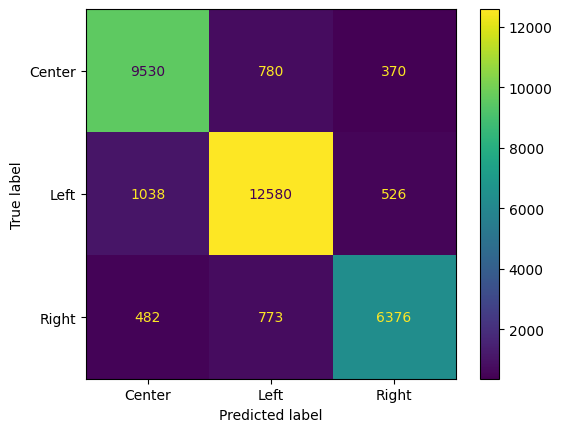

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute evaluation metrics
print(f'Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}')

# Show confusion matrix
print('\nConfusion Matrix:')
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Center', 'Left', 'Right'])
disp.plot()
gc.collect()


In [26]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │    39,442,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,017,743 (152.66 MB)

 Trainable params: 191,747 (749.01 KB)

 Non-trainable params: 39,442,500 (150.46 MB)

 Optimizer params: 383,496 (1.46 MB)

None


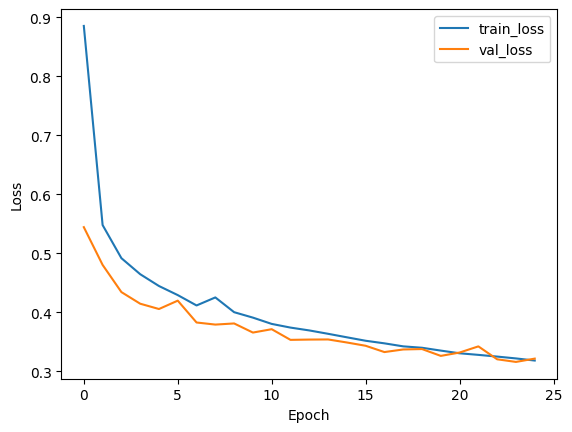

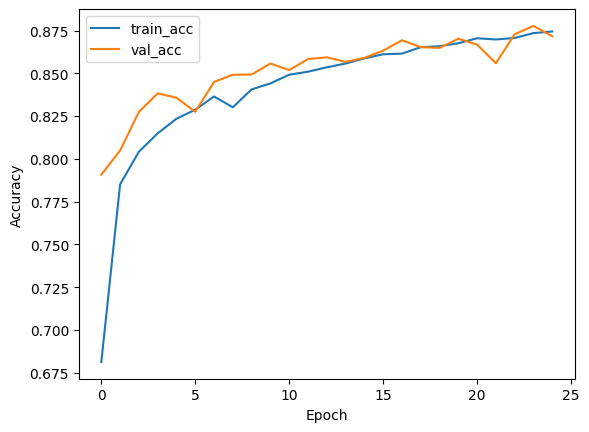

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [28]:
# Save the full model
model.save('polusa_BiLSTM_64-64-03.keras')